# Step#1 Load and inspect Data


In [154]:
import pandas as pd
import numpy as np

In [155]:
df = pd.read_csv("insurance.csv")

In [156]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [157]:
df.shape

(1338, 7)

In [158]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [159]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [160]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [161]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Step#2: Null values


In [163]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [164]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [165]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [166]:
for i in df.columns:
    print(i, df[i].dtypes, df[i].isna().sum())

age int64 0
sex object 0
bmi float64 0
children int64 0
smoker object 0
region object 0
charges float64 0


In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

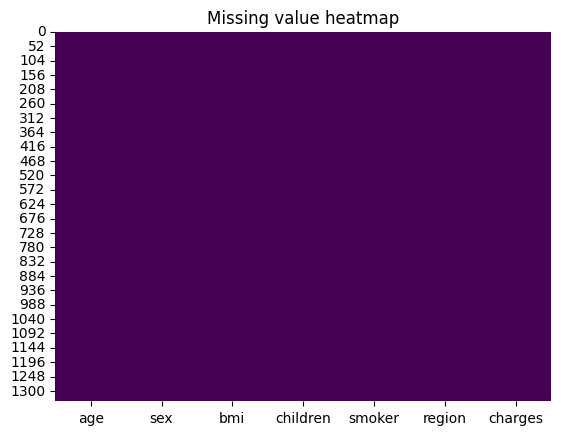

In [168]:
sns.heatmap(df.isnull(), cbar = False , cmap = "viridis")
plt.title("Missing value heatmap")
plt.show()

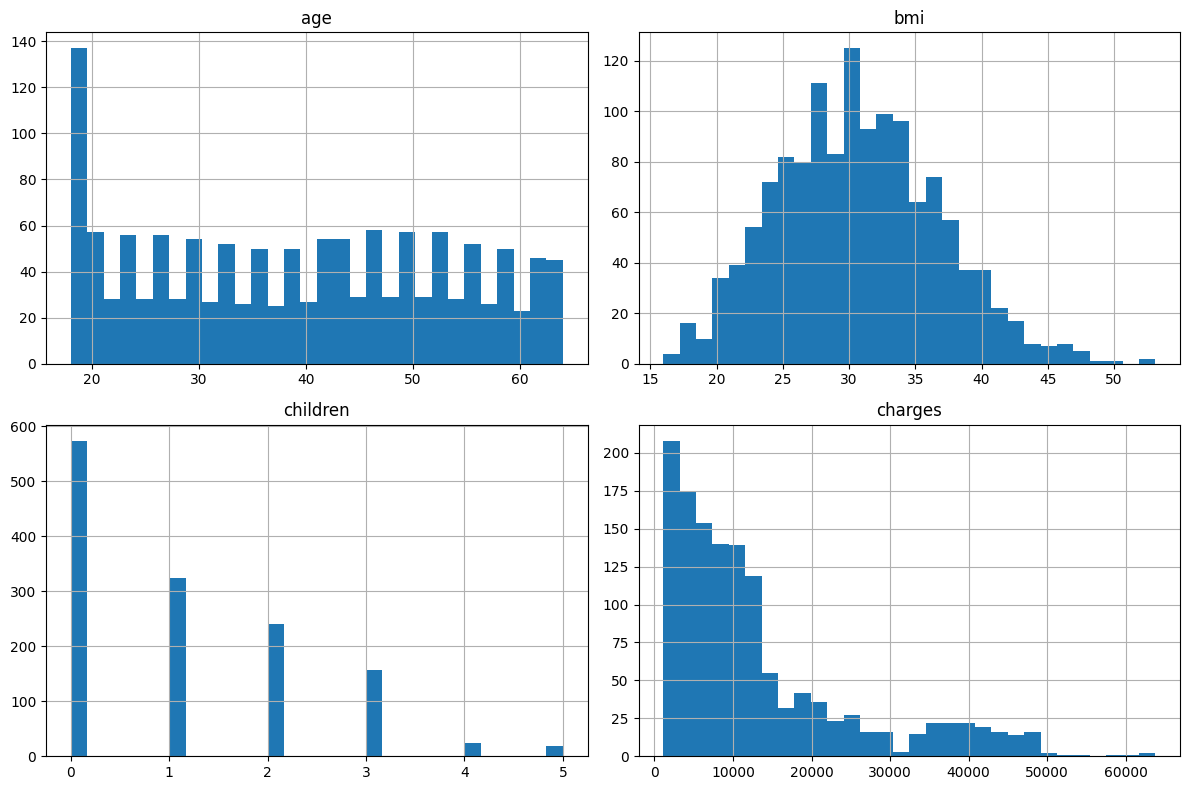

In [169]:
df.hist(figsize = (12,8), bins = 30)
plt.tight_layout()
plt.show()

# Categorical columns.

In [170]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [171]:
for i in df:
    if(df[i].dtypes == 'object'):
        df[i] = le.fit_transform(df[i])
        print(i,df[i].dtypes )

sex int64
smoker int64
region int64


In [181]:
df = pd.get_dummies(df, drop_first=True)

In [172]:
correlation = df.corr()
correlation

,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.002127,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.004588,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.157566,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.016569,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,-0.002181,0.787251
region,0.002127,0.004588,0.157566,0.016569,-0.002181,1.000000,-0.006208
charges,0.299008,0.057292,0.198341,0.067998,0.787251,-0.006208,1.000000


<Axes: >

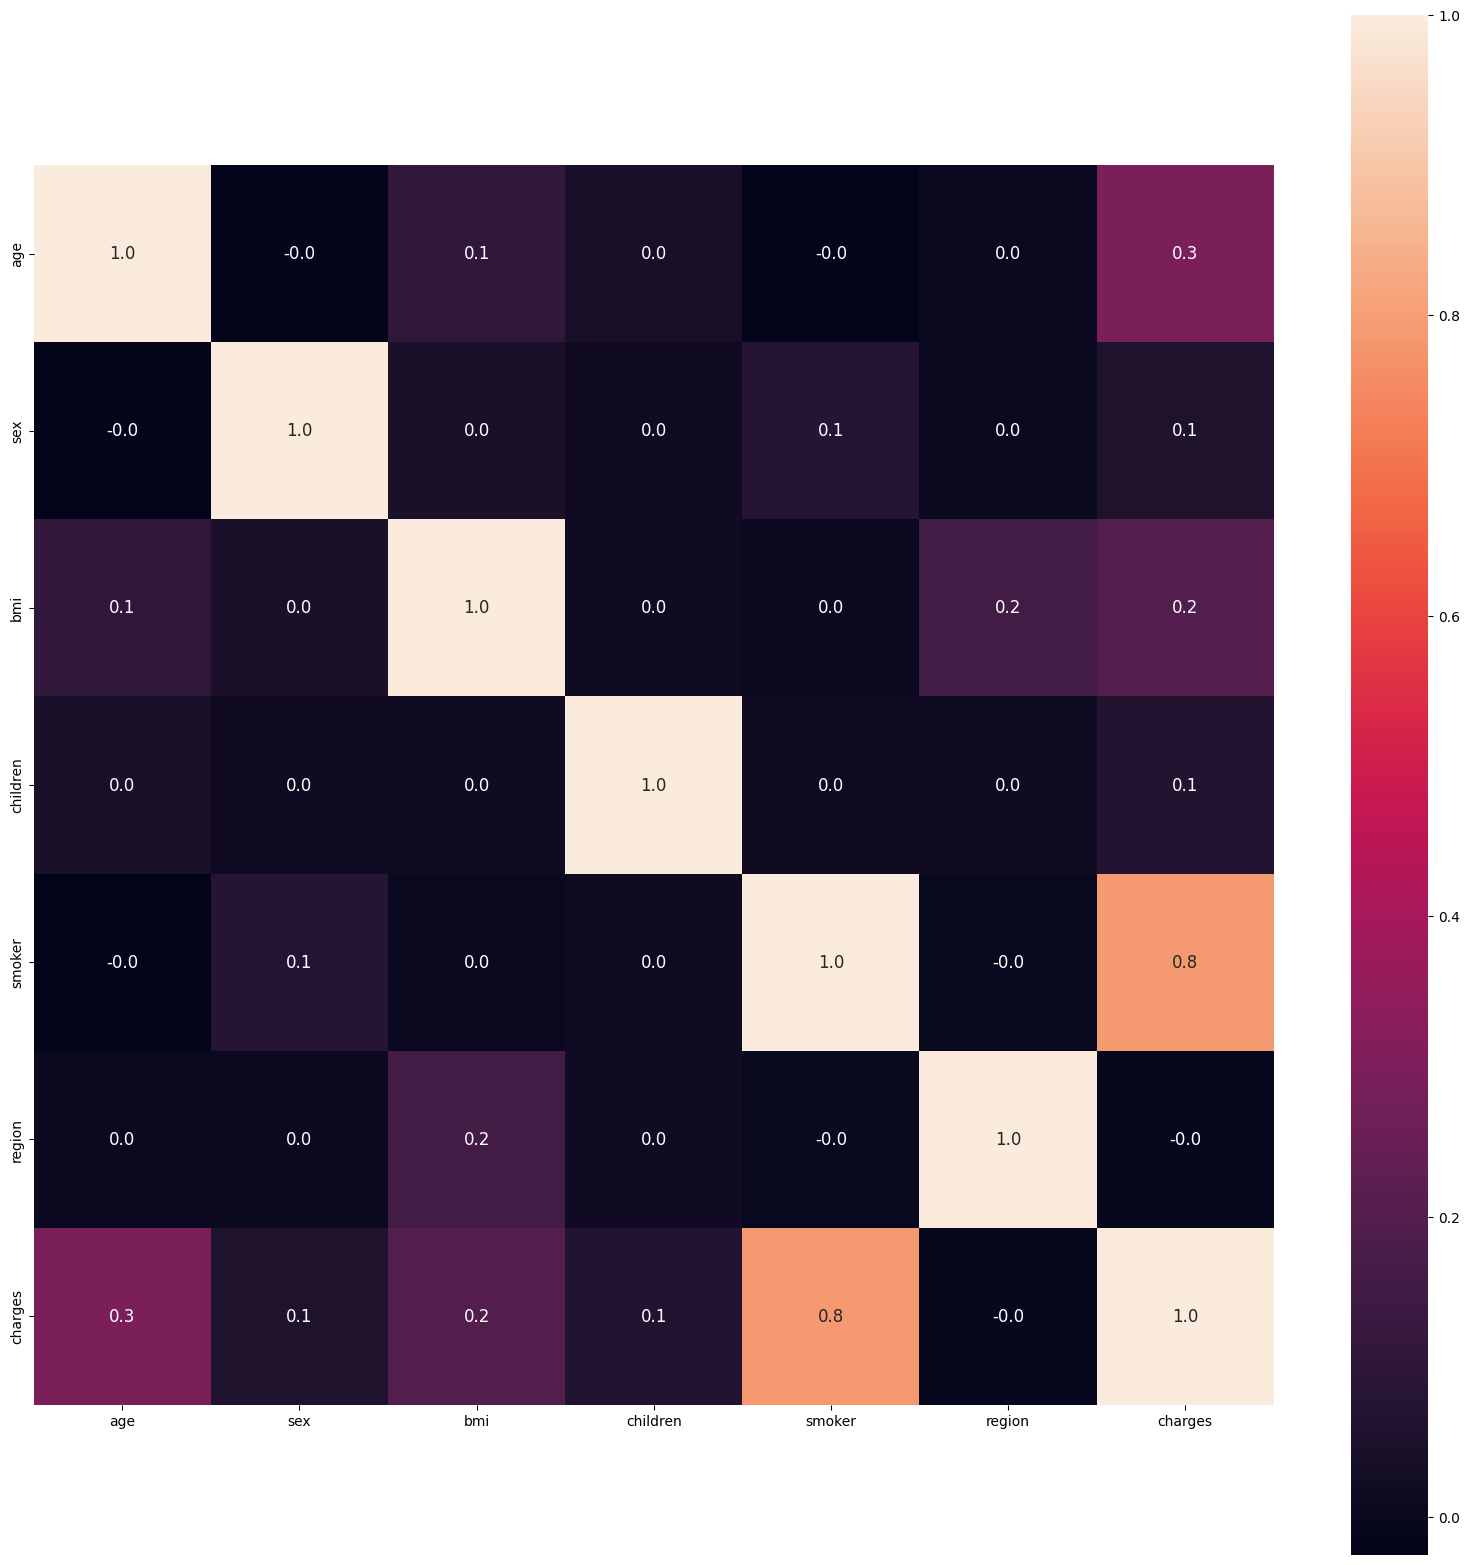

In [173]:
plt.figure(figsize=(20,20))
sns.heatmap(correlation , square = True, fmt = '.1f',annot = True, annot_kws = {'size':12})

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1338 non-null   int64  
 1   sex          1338 non-null   int64  
 2   bmi          1338 non-null   float64
 3   children     1338 non-null   int64  
 4   smoker       1338 non-null   int64  
 5   region       1338 non-null   int64  
 6   charges      1338 non-null   float64
 7   age_squared  1338 non-null   int64  
 8   log_charges  1338 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 94.2 KB


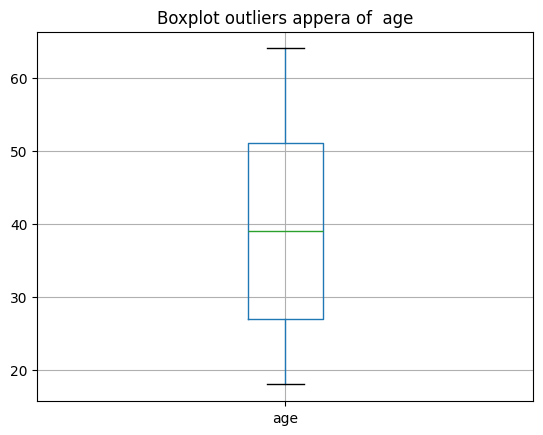

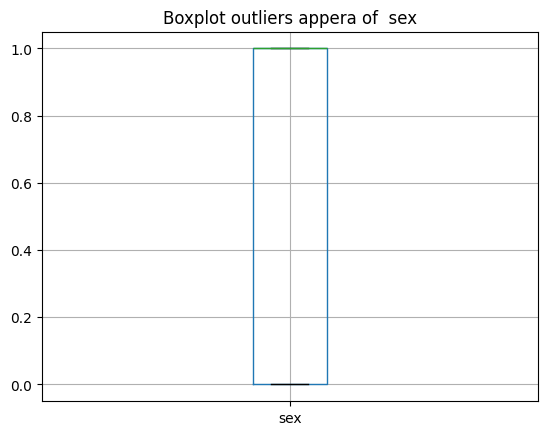

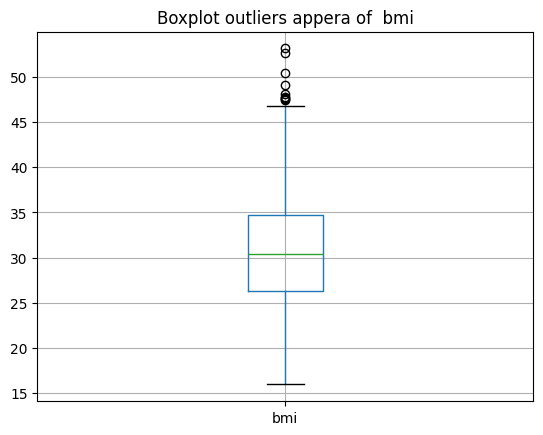

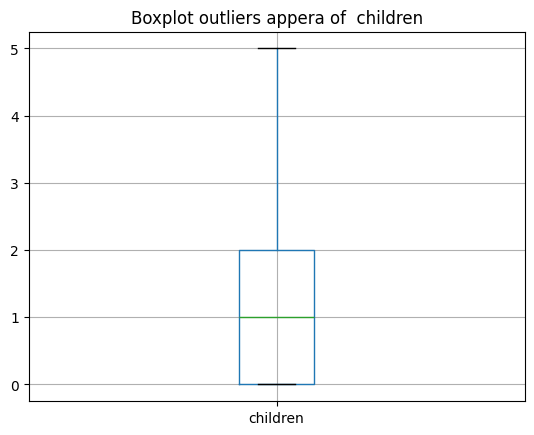

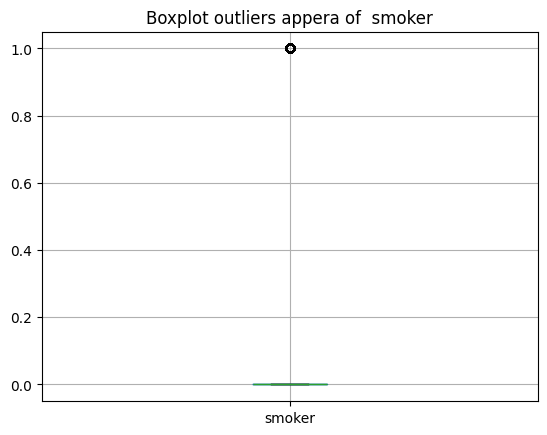

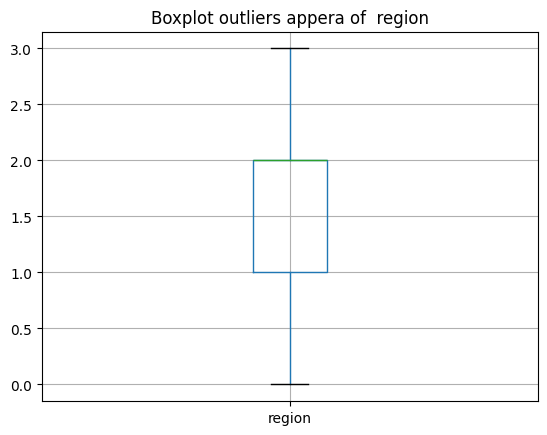

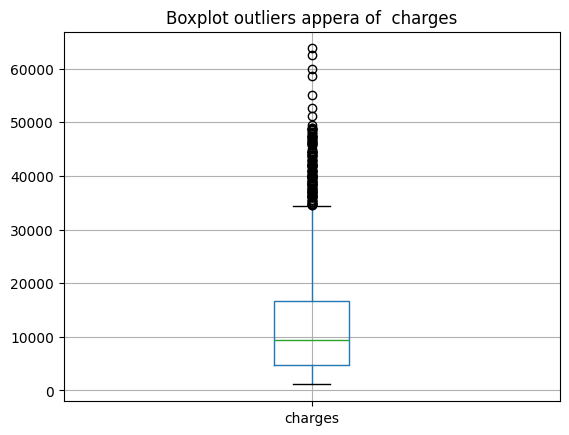

In [175]:
for i in df.columns:
    pd.DataFrame(df[i]).boxplot()
    plt.title("Boxplot outliers appera of  " + i)
    plt.show()

# Feature engineering.

In [184]:
df['bmi_smoker'] = df['bmi'] * df['smoker']

In [177]:
df['age_squared'] = df['age'] ** 2

In [179]:
df['log_charges'] = np.log(df['charges'])

In [187]:
X = df.drop(['charges', 'log_charges'], axis=1)

y = df['log_charges']

len(X)


1338

In [189]:
len(y)

1338

# Train/Split

In [185]:
from sklearn.model_selection import train_test_split

In [188]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [190]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [192]:
# XGB Boost

In [193]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [194]:
training_data_prediction = xgb.predict(X_train)
print(training_data_prediction)

[ 9.115595   9.233626   9.339888  ...  9.3962145 10.626211   9.346287 ]


In [195]:
from sklearn.metrics import(
mean_absolute_error, mean_squared_error, r2_score,
mean_absolute_percentage_error
)

In [196]:
r2 = r2_score(y_train, training_data_prediction)
mea = mean_absolute_error(y_train, training_data_prediction)
mse = mean_squared_error (y_train, training_data_prediction)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.8729
MAE :  0.1689
MSE :  0.1055
RMSE :  0.3249


In [197]:
y_pred = xgb.predict(X_test)
y_pred[: 5]

array([ 9.254114,  8.617862, 10.208373,  9.133545, 10.337867],
      dtype=float32)

In [198]:
r2 = r2_score(y_test, y_pred)
mea = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error (y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.8672
MAE :  0.1779
MSE :  0.1194
RMSE :  0.3456


In [199]:
# Random forest

In [200]:
from sklearn.ensemble import RandomForestRegressor

In [201]:
regressor = RandomForestRegressor (n_estimators = 5, random_state = 25)
regressor.fit(X_train, y_train)

RandomForestRegressor(n_estimators=5, random_state=25)

In [202]:
training_data_prediction = regressor.predict(X_train)
print(training_data_prediction)

[ 9.09549245  9.49662832  9.78043557 ...  9.38690583 10.72835365
  9.37216457]


In [203]:
r2 = r2_score(y_train, training_data_prediction)
mea = mean_absolute_error(y_train, training_data_prediction)
mse = mean_squared_error (y_train, training_data_prediction)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.9494
MAE :  0.0879
MSE :  0.0420
RMSE :  0.2050


In [204]:
y_predict = regressor.predict(X_test)
y_predict[: 5]

array([ 9.00468796,  8.56198327, 10.2588467 ,  9.12453355, 10.470641  ])

In [205]:
r2 = r2_score(y_test, y_pred)
mea = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error (y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.8672
MAE :  0.1779
MSE :  0.1194
RMSE :  0.3456


In [206]:
# Ridge regression

In [207]:
from sklearn.linear_model import Ridge


In [211]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

Ridge()

In [212]:
training_data_prediction = ridge.predict(X_train)
print(training_data_prediction)

[ 9.17392581  9.10012962  9.15200452 ...  9.32617208 11.22037801
  9.1121634 ]


In [213]:
r2 = r2_score(y_train, training_data_prediction)
mea = mean_absolute_error(y_train, training_data_prediction)
mse = mean_squared_error (y_train, training_data_prediction)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.7749
MAE :  0.2707
MSE :  0.1869
RMSE :  0.4324


In [220]:
y_predict = ridge.predict(X_test)
y_predict[: 5]

array([ 9.20805711,  8.69838033, 10.89623742,  9.18615562,  9.54823326])

In [221]:
r2 = r2_score(y_test, y_pred)
mea = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error (y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.8672
MAE :  0.1779
MSE :  0.1194
RMSE :  0.3456


In [216]:
# Decission Tree

In [217]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, min_samples_leaf=5, random_state=42)

In [218]:
training_data_prediction = dt.predict(X_train)
print(training_data_prediction)

[ 9.10709307  9.34389265  9.34389265 ...  9.34389265 10.65269713
  9.34389265]


In [219]:
r2 = r2_score(y_train, training_data_prediction)
mea = mean_absolute_error(y_train, training_data_prediction)
mse = mean_squared_error (y_train, training_data_prediction)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.8283
MAE :  0.2190
MSE :  0.1425
RMSE :  0.3775


In [222]:
y_predict = dt.predict(X_test)
y_predict[: 5]

array([ 9.10709307,  8.80137006, 10.21256137,  9.10709307, 10.46342246])

In [223]:
r2 = r2_score(y_test, y_pred)
mea = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error (y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.8672
MAE :  0.1779
MSE :  0.1194
RMSE :  0.3456


In [224]:
# SVr

In [225]:
from sklearn.svm import SVR

In [226]:
svr = SVR(kernel = 'linear')
svr.fit(X_train,y_train)

SVR(kernel='linear')

In [227]:
training_data_prediction = svr.predict(X_train)
print(training_data_prediction)

[ 9.59460341  9.43164317  9.62039867 ... 10.02911667 11.78983973
  9.41842056]


In [228]:
r2 = r2_score(y_train, training_data_prediction)
mea = mean_absolute_error(y_train, training_data_prediction)
mse = mean_squared_error (y_train, training_data_prediction)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.4559
MAE :  0.4704
MSE :  0.4518
RMSE :  0.6721


In [229]:
y_predict = svr.predict(X_test)
y_predict[: 5]

array([ 9.62185593,  8.60213595, 12.52962282,  9.40247374,  9.58330656])

In [230]:
r2 = r2_score(y_test, y_pred)
mea = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error (y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R2 : {r2 : .4f}")
print (f"MAE : {mea: .4f}")
print(f"MSE : {mse : .4f}")
print(f"RMSE : {rmse : .4f}")

R2 :  0.8672
MAE :  0.1779
MSE :  0.1194
RMSE :  0.3456
